In [1]:
# Diabetes Progression Predictor
# BIOTECHTREK AI in Healthcare & Drug Discovery Capstone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the diabetes dataset

data = load_diabetes(as_frame=True)

# Convert it into a pandas DataFrame
df = data.frame

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (442, 11)


In [3]:
# Display the first 5 rows

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
# Check the dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 442
Number of columns: 11

Column names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


In [5]:
# Basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
# Statistical summary

df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [7]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Total missing values: 0


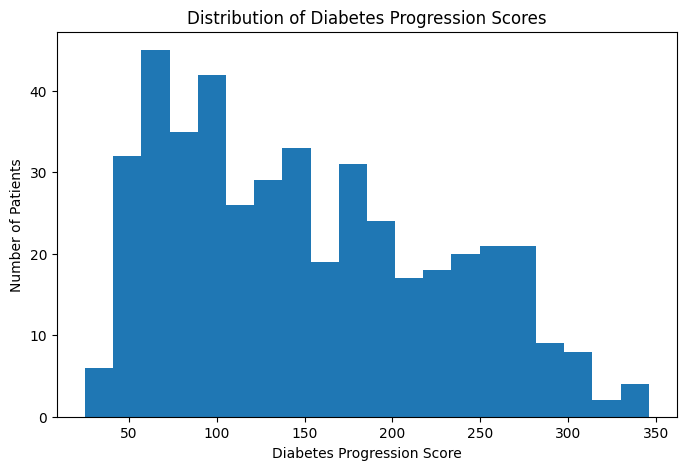

In [8]:
# Distribution of diabetes progression scores

plt.figure(figsize=(8, 5))
plt.hist(df['target'], bins=20)
plt.xlabel('Diabetes Progression Score')
plt.ylabel('Number of Patients')
plt.title('Distribution of Diabetes Progression Scores')
plt.show()

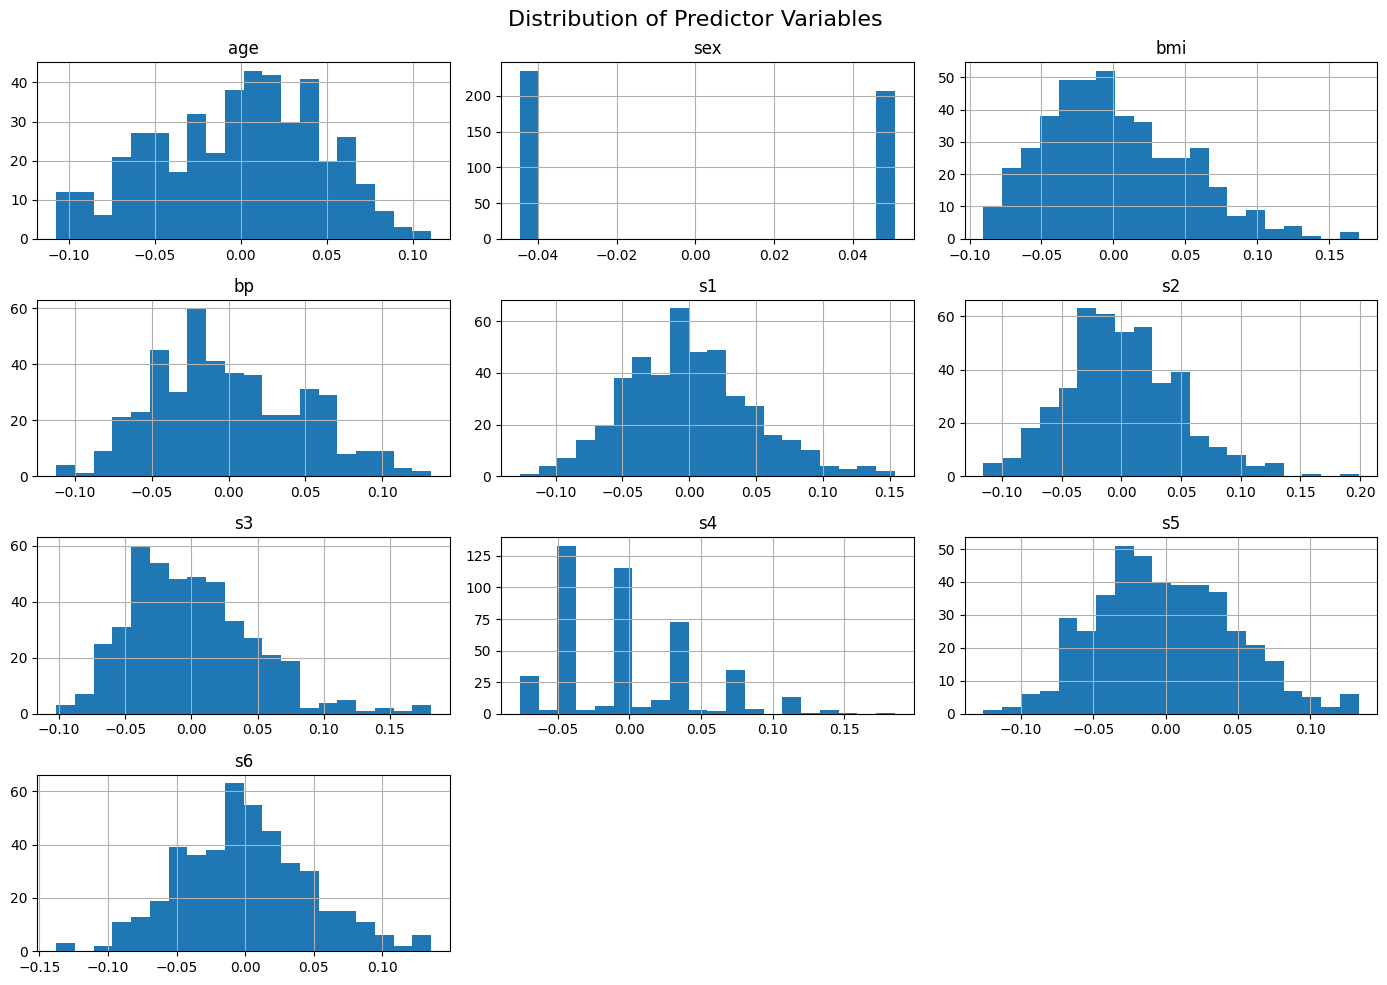

In [9]:
# Histograms of predictor variables

df.drop(columns='target').hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle('Distribution of Predictor Variables', fontsize=16)
plt.tight_layout()
plt.show()

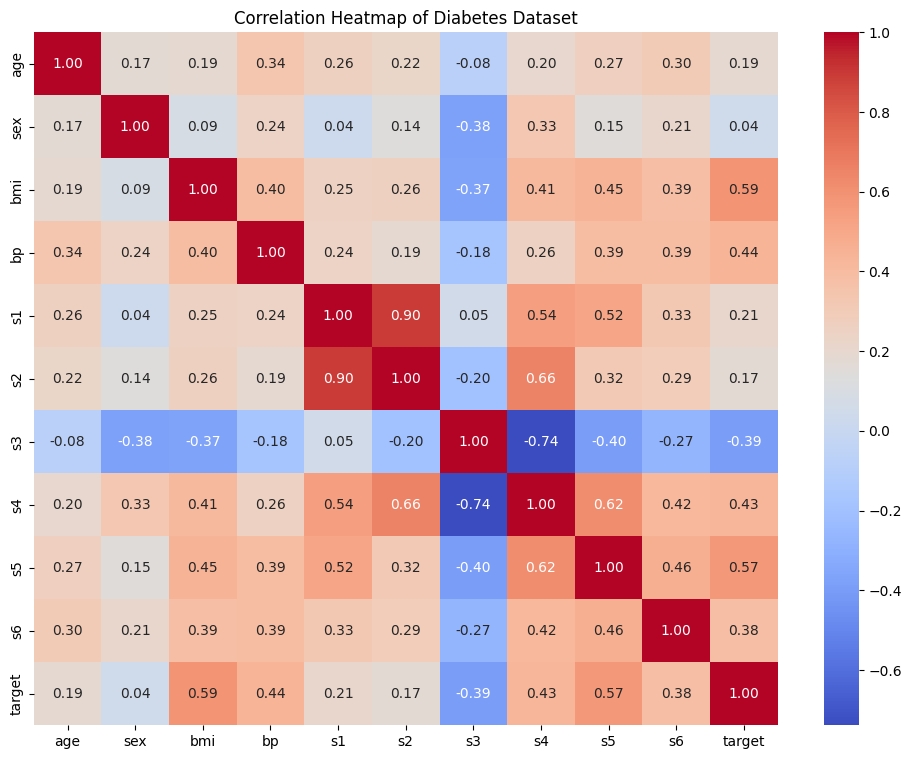

In [10]:
# Correlation heatmap

plt.figure(figsize=(12, 9))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()

### Correlation Analysis

The correlation heatmap was used to examine relationships among the predictor variables and the diabetes progression target. BMI showed the strongest positive correlation with the target (r = 0.59), followed by s5 (r = 0.57). BP (r = 0.44), s4 (r = 0.43), and s6 (r = 0.38) also showed positive associations with the target.

The variable s3 showed a moderate negative correlation with the target (r = -0.39), while sex showed very little linear correlation with the target (r = 0.04).

Strong correlations were also observed among some predictor variables, particularly between s1 and s2 (r = 0.90) and between s3 and s4 (r = -0.74). These relationships indicate that some predictors contain overlapping information.

In [13]:
# Separate features and target
X = df.drop(columns='target')
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (442, 10)
Target shape: (442,)


In [14]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (353, 10)
Testing features: (89, 10)
Training target: (353,)
Testing target: (89,)


In [15]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (353, 10)
Scaled testing data shape: (89, 10)


In [16]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [17]:
# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_scaled)

print("First 10 predictions:")
print(y_pred_linear[:10])

First 10 predictions:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("Mean Absolute Error (MAE):", round(mae_linear, 2))
print("R² Score:", round(r2_linear, 2))

Linear Regression Results
-------------------------
Mean Absolute Error (MAE): 42.79
R² Score: 0.45


In [19]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [20]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("First 10 Random Forest predictions:")
print(y_pred_rf[:10])

First 10 Random Forest predictions:
[144.   171.58 150.72 253.71 107.19 123.54 239.09 219.01 153.44 184.59]


In [21]:
# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("Mean Absolute Error (MAE):", round(mae_rf, 2))
print("R² Score:", round(r2_rf, 2))

Random Forest Results
--------------------
Mean Absolute Error (MAE): 44.05
R² Score: 0.44


In [22]:
# Try a few Random Forest configurations

rf_200 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rf_200.fit(X_train, y_train)

y_pred_rf_200 = rf_200.predict(X_test)

mae_rf_200 = mean_absolute_error(y_test, y_pred_rf_200)
r2_rf_200 = r2_score(y_test, y_pred_rf_200)

print("Random Forest (200 trees)")
print("------------------------")
print("MAE:", round(mae_rf_200, 2))
print("R² Score:", round(r2_rf_200, 2))

Random Forest (200 trees)
------------------------
MAE: 44.28
R² Score: 0.44


In [23]:
# Compare all models

comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (100 trees)',
        'Random Forest (200 trees)'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_rf_200
    ],
    'R² Score': [
        r2_linear,
        r2_rf,
        r2_rf_200
    ]
})

print(comparison.round(2))

                       Model    MAE  R² Score
0          Linear Regression  42.79      0.45
1  Random Forest (100 trees)  44.05      0.44
2  Random Forest (200 trees)  44.28      0.44


Model Comparison

Linear Regression achieved the best performance among the models tested, with an MAE of 42.79 and an R² score of 0.45. The Random Forest models produced slightly higher MAE values and slightly lower R² scores. Therefore, Linear Regression was selected as the final model for the Diabetes Progression Prediction project.

In [24]:
import joblib

# Save the final Linear Regression model
joblib.dump(linear_model, 'diabetes_linear_model.joblib')

# Save the scaler used for preprocessing
joblib.dump(scaler, 'diabetes_scaler.joblib')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [25]:
import os

print("Model file exists:", os.path.exists('diabetes_linear_model.joblib'))
print("Scaler file exists:", os.path.exists('diabetes_scaler.joblib'))

Model file exists: True
Scaler file exists: True


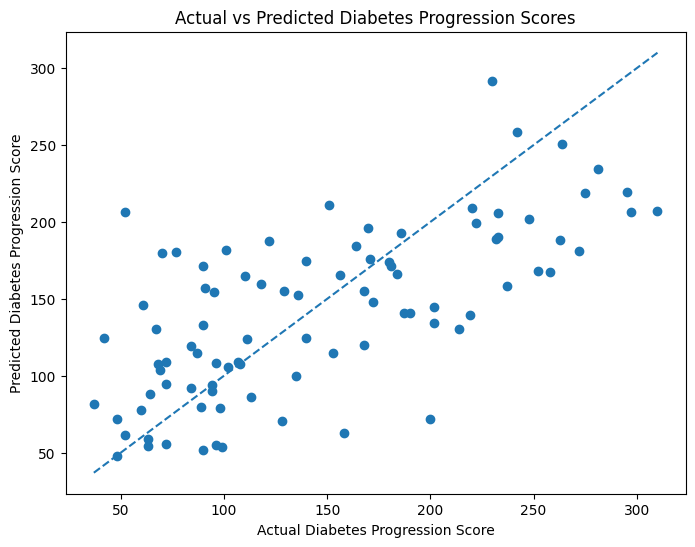

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Diabetes Progression Score')
plt.ylabel('Predicted Diabetes Progression Score')
plt.title('Actual vs Predicted Diabetes Progression Scores')

plt.show()

### Actual vs Predicted Values

The actual versus predicted plot shows the performance of the final Linear Regression model on the test dataset. The dashed diagonal line represents perfect predictions. The predicted values show some deviation from the actual values, which is consistent with the model's R² score of 0.45 and MAE of 42.79.

The predictions show a tendency toward the middle of the target range, indicating that the model does not fully capture the variation in diabetes progression scores.

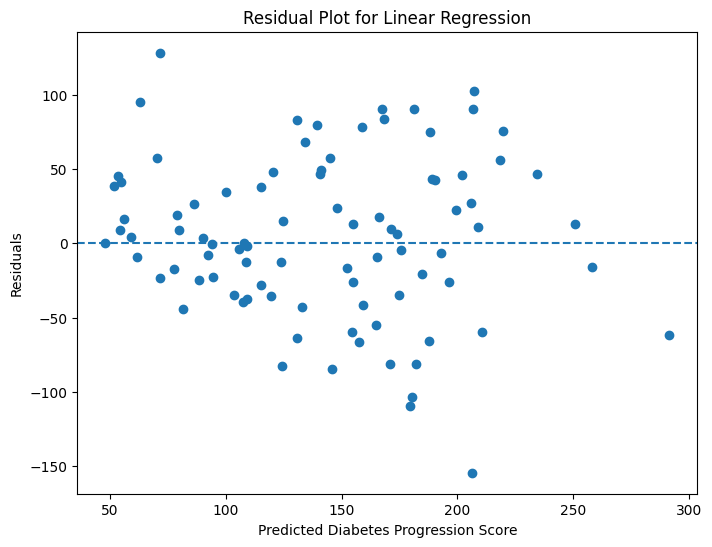

In [27]:
# Calculate residuals
residuals = y_test - y_pred_linear

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_linear, residuals)

# Zero-error reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Diabetes Progression Score')
plt.ylabel('Residuals')
plt.title('Residual Plot for Linear Regression')

plt.show()

In [28]:
# Select the best-performing model
final_model = linear_model

print("Final model selected: Linear Regression")
print("Final MAE:", round(mae_linear, 2))
print("Final R² Score:", round(r2_linear, 2))

Final model selected: Linear Regression
Final MAE: 42.79
Final R² Score: 0.45


In [29]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load the trained model and scaler
model = joblib.load("diabetes_linear_model.joblib")
scaler = joblib.load("diabetes_scaler.joblib")

# Page title
st.title("Diabetes Progression Predictor")

st.write(
    "This application uses a machine learning model to predict "
    "a diabetes progression score based on 10 input features."
)

st.info(
    "This tool is for educational purposes only and is not intended "
    "for medical diagnosis or clinical decision-making."
)

st.subheader("Enter Patient Features")

# Input fields
age = st.number_input("Age", value=0.0)
sex = st.number_input("Sex", value=0.0)
bmi = st.number_input("BMI", value=0.0)
bp = st.number_input("Blood Pressure (BP)", value=0.0)
s1 = st.number_input("S1", value=0.0)
s2 = st.number_input("S2", value=0.0)
s3 = st.number_input("S3", value=0.0)
s4 = st.number_input("S4", value=0.0)
s5 = st.number_input("S5", value=0.0)
s6 = st.number_input("S6", value=0.0)

# Prediction button
if st.button("Predict Diabetes Progression Score"):

    # Arrange inputs in the same order as the training dataset
    input_data = pd.DataFrame(
        [[age, sex, bmi, bp, s1, s2, s3, s4, s5, s6]],
        columns=["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]
    )

    # Scale the input using the saved scaler
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = model.predict(input_scaled)[0]

    st.success(
        f"Predicted Diabetes Progression Score: {prediction:.2f}"
    )

Writing app.py


In [30]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
joblib

Writing requirements.txt


In [31]:
import os

files = [
    "diabetes_linear_model.joblib",
    "diabetes_scaler.joblib",
    "app.py",
    "requirements.txt"
]

for file in files:
    print(file, "->", os.path.exists(file))

diabetes_linear_model.joblib -> True
diabetes_scaler.joblib -> True
app.py -> True
requirements.txt -> True


In [32]:
%%writefile README.md

# Diabetes Progression Prediction Using Machine Learning

## Project Overview

This project uses machine learning to predict a numerical diabetes progression score using clinical features from the scikit-learn diabetes dataset.

The project was developed as part of the BIOTECHTREK AI in Healthcare & Drug Discovery Bootcamp.

## Objective

The objective is to develop and evaluate regression models for predicting diabetes progression and deploy the best-performing model through a simple Streamlit application.

## Dataset

The project uses the built-in `load_diabetes()` dataset from scikit-learn.

The dataset contains:

- 442 observations
- 10 predictor variables
- 1 target variable representing a diabetes progression score

## Models Used

Two regression approaches were evaluated:

1. Linear Regression
2. Random Forest Regressor

Random Forest models with 100 and 200 trees were also compared.

## Model Evaluation

The models were evaluated using:

- Mean Absolute Error (MAE)
- R² Score

### Final Results

| Model | MAE | R² Score |
|---|---:|---:|
| Linear Regression | 42.79 | 0.45 |
| Random Forest (100 trees) | 44.05 | 0.44 |
| Random Forest (200 trees) | 44.28 | 0.44 |

Linear Regression was selected as the final model because it achieved the lowest MAE and highest R² score among the tested models.

## Application

A Streamlit application was developed to allow users to enter the model features and obtain a predicted diabetes progression score.

## Disclaimer

This application is intended for educational purposes only. It is not a medical diagnostic tool and should not be used for clinical decision-making.

## Project Files

- `diabetes_project.ipynb` - Main analysis notebook
- `app.py` - Streamlit application
- `diabetes_linear_model.joblib` - Trained Linear Regression model
- `diabetes_scaler.joblib` - Feature scaler
- `requirements.txt` - Required Python packages

Writing README.md


In [33]:
import os

project_files = [
    "app.py",
    "requirements.txt",
    "README.md",
    "diabetes_linear_model.joblib",
    "diabetes_scaler.joblib"
]

print("Project files:")
print("----------------")

for file in project_files:
    print(f"{file}: {os.path.exists(file)}")

Project files:
----------------
app.py: True
requirements.txt: True
README.md: True
diabetes_linear_model.joblib: True
diabetes_scaler.joblib: True


In [34]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load trained model and scaler
model = joblib.load("diabetes_linear_model.joblib")
scaler = joblib.load("diabetes_scaler.joblib")

# Page configuration
st.set_page_config(
    page_title="Diabetes Progression Predictor",
    page_icon="🧬",
    layout="centered"
)

# Title
st.title("🧬 Diabetes Progression Predictor")

st.write(
    "This application uses a Linear Regression machine learning model "
    "to predict a numerical diabetes progression score."
)

st.info(
    "Educational project only. This application is not a medical "
    "diagnostic tool and should not be used for clinical decision-making."
)

st.markdown("### About the inputs")

st.write(
    "The features below use the standardized numerical representation "
    "provided by the scikit-learn diabetes dataset. They are not direct "
    "clinical measurements such as ordinary BMI or blood pressure values."
)

st.markdown("### Enter standardized feature values")

# Input features
age = st.number_input(
    "Age",
    min_value=-0.2,
    max_value=0.2,
    value=0.0,
    step=0.01
)

sex = st.number_input(
    "Sex",
    min_value=-0.05,
    max_value=0.05,
    value=0.0,
    step=0.01
)

bmi = st.number_input(
    "BMI",
    min_value=-0.1,
    max_value=0.2,
    value=0.0,
    step=0.01
)

bp = st.number_input(
    "Blood Pressure (BP)",
    min_value=-0.12,
    max_value=0.13,
    value=0.0,
    step=0.01
)

s1 = st.number_input(
    "S1",
    min_value=-0.13,
    max_value=0.16,
    value=0.0,
    step=0.01
)

s2 = st.number_input(
    "S2",
    min_value=-0.12,
    max_value=0.20,
    value=0.0,
    step=0.01
)

s3 = st.number_input(
    "S3",
    min_value=-0.1,
    max_value=0.18,
    value=0.0,
    step=0.01
)

s4 = st.number_input(
    "S4",
    min_value=-0.1,
    max_value=0.19,
    value=0.0,
    step=0.01
)

s5 = st.number_input(
    "S5",
    min_value=-0.13,
    max_value=0.13,
    value=0.0,
    step=0.01
)

s6 = st.number_input(
    "S6",
    min_value=-0.14,
    max_value=0.14,
    value=0.0,
    step=0.01
)

# Prediction
if st.button("🔬 Predict Diabetes Progression Score"):

    input_data = pd.DataFrame(
        [[age, sex, bmi, bp, s1, s2, s3, s4, s5, s6]],
        columns=[
            "age", "sex", "bmi", "bp",
            "s1", "s2", "s3", "s4", "s5", "s6"
        ]
    )

    # Apply the same preprocessing used during training
    input_scaled = scaler.transform(input_data)

    # Generate prediction
    prediction = model.predict(input_scaled)[0]

    st.success(
        f"### Predicted Diabetes Progression Score: {prediction:.2f}"
    )

    st.caption(
        "Model: Linear Regression | Test MAE: 42.79 | Test R²: 0.45"
    )

Overwriting app.py


In [35]:
with open("app.py", "r") as f:
    app_code = f.read()

print("app.py successfully updated!")
print("Number of lines:", len(app_code.splitlines()))

app.py successfully updated!
Number of lines: 144
